In [ ]:
#observation 2.4

Saved: C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\ICST2026\rq2_obs24_heatmap_rowshare.png


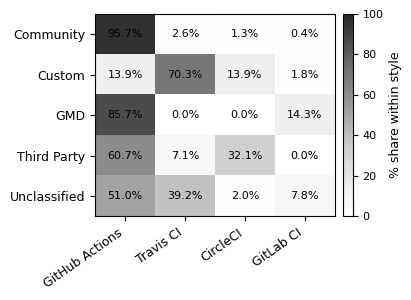


Counts used (binary per repo; single-style only; Real Device excluded):
{'style': 'Community', 'N': 224, 'GitHub Actions': 224, 'Travis CI': 6, 'CircleCI': 3, 'GitLab CI': 1}
{'style': 'Custom', 'N': 149, 'GitHub Actions': 23, 'Travis CI': 116, 'CircleCI': 23, 'GitLab CI': 3}
{'style': 'GMD', 'N': 7, 'GitHub Actions': 6, 'Travis CI': 0, 'CircleCI': 0, 'GitLab CI': 1}
{'style': 'Third Party', 'N': 27, 'GitHub Actions': 17, 'Travis CI': 2, 'CircleCI': 9, 'GitLab CI': 0}
{'style': 'Unclassified', 'N': 50, 'GitHub Actions': 26, 'Travis CI': 20, 'CircleCI': 1, 'GitLab CI': 4}


In [11]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# CONFIG
# ============================================================
CSV_PATH = r"C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\ICST2026\5_Total_Repo.csv"
OUT_PNG  = r"C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\ICST2026\rq2_obs24_heatmap_rowshare.png"

# Use the CI-service columns that exist in YOUR dataset
# (These are present in your 5_Total_Repo.csv as counts of config files.)
SERVICE_COLS = [
    ("GitHub Actions", "github_actions"),
    ("Travis CI",      "travis_ci"),
    ("CircleCI",       "circle_ci"),
    ("GitLab CI",      "gitlab"),
]

STYLE_ORDER = ["Community", "Custom", "GMD", "Third Party", "Unclassified"]  # Real Device excluded

# Lighter heatmap look
CMAP = "Greys"
ALPHA = 0.85

# Single-column friendly size (tweak if you want)
FIG_W, FIG_H = 4.2, 3.1

# ============================================================
# Helpers
# ============================================================
def norm_bool(x) -> bool:
    s = str(x).strip().lower()
    return s in {"1", "true", "t", "yes", "y"}

def map_styles(exec_env_style) -> list[str]:
    """
    Maps dataset tokens (e.g., Emu_Community, Emu_Custom, Emu_GMD, Third-Party, Real Device)
    into paper labels: Community, Custom, GMD, Third Party, Real Device.
    If nothing is detectable -> Unclassified.
    """
    s = "" if pd.isna(exec_env_style) else str(exec_env_style)
    toks = [t.strip() for t in s.split(",") if t.strip()]

    mapped = []
    for t in toks:
        tl = t.lower()
        if "community" in tl:
            mapped.append("Community")
        elif "custom" in tl:
            mapped.append("Custom")
        elif "gmd" in tl or "managed" in tl:
            mapped.append("GMD")
        elif "third" in tl:
            mapped.append("Third Party")
        elif "real" in tl and "device" in tl:
            mapped.append("Real Device")

    if not mapped:
        return ["Unclassified"]
    return sorted(set(mapped))

def to_binary_presence(series: pd.Series) -> pd.Series:
    """
    Dataset stores provider columns as counts (# config files).
    Convert to binary presence: >0 => True.
    """
    x = pd.to_numeric(series, errors="coerce").fillna(0)
    return x > 0

# ============================================================
# Load + filter
# ============================================================
p = Path(CSV_PATH)
if not p.exists():
    raise FileNotFoundError(f"CSV not found: {CSV_PATH}")

df = pd.read_csv(p)

# Adopters only
if "instru_t_ci_signal" not in df.columns:
    raise ValueError("Expected column 'instru_t_ci_signal' in the dataset.")

df["adopt"] = df["instru_t_ci_signal"].apply(norm_bool)
adopters = df[df["adopt"]].copy()

# Map styles and keep single-style only
adopters["style_list"] = adopters["Exec_Env_Style"].apply(map_styles)
adopters["style_count"] = adopters["style_list"].apply(len)
single = adopters[adopters["style_count"] == 1].copy()
single["style"] = single["style_list"].apply(lambda x: x[0])

# Exclude Real Device (as per your paper decision)
single = single[single["style"] != "Real Device"].copy()

# Ensure required CI columns exist
missing = [col for _, col in SERVICE_COLS if col not in single.columns]
if missing:
    raise ValueError(f"Missing CI service columns in dataset: {missing}")

# ============================================================
# Build matrix:
# Cell% = share of CI-service footprint within that style row
# Denominator = sum over services of (#repos in style with that service present)
# ============================================================
M = np.full((len(STYLE_ORDER), len(SERVICE_COLS)), np.nan)

for i, style in enumerate(STYLE_ORDER):
    g = single[single["style"] == style].copy()

    # Count binary presence per service (repos may count in multiple services)
    counts = []
    for _, col in SERVICE_COLS:
        counts.append(int(to_binary_presence(g[col]).sum()))

    denom = sum(counts)

    if denom == 0:
        # No footprint across the selected CI services => leave row as NaN
        continue

    for j, c in enumerate(counts):
        M[i, j] = (c / denom) * 100.0

# ============================================================
# Plot heatmap
# ============================================================
fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))

im = ax.imshow(M, aspect="auto", cmap=CMAP, vmin=0, vmax=100, alpha=ALPHA)

ax.set_yticks(range(len(STYLE_ORDER)))
ax.set_yticklabels(STYLE_ORDER, fontsize=9)

ax.set_xticks(range(len(SERVICE_COLS)))
ax.set_xticklabels([name for name, _ in SERVICE_COLS], rotation=35, ha="right", fontsize=9)

# Annotate
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        if np.isnan(M[i, j]):
            continue
        ax.text(j, i, f"{M[i,j]:.1f}%", ha="center", va="center", fontsize=8, color="black")

#ax.set_title("CI-service footprint distribution by style (single-style adopters)", fontsize=10)
#ax.set_xlabel("CI service", fontsize=9)
#ax.set_ylabel("Execution-environment style", fontsize=9)

# Colorbar
cbar = fig.colorbar(im, ax=ax, fraction=0.06, pad=0.03)
cbar.ax.tick_params(labelsize=8)
cbar.set_label("% share within style", fontsize=9)

fig.tight_layout()
fig.savefig(OUT_PNG, dpi=300)
print(f"Saved: {OUT_PNG}")
plt.show()

# ============================================================
# Optional: print the underlying counts (useful for sanity-checking)
# ============================================================
print("\nCounts used (binary per repo; single-style only; Real Device excluded):")
for style in STYLE_ORDER:
    g = single[single["style"] == style].copy()
    row = {"style": style, "N": len(g)}
    for name, col in SERVICE_COLS:
        row[name] = int(to_binary_presence(g[col]).sum())
    print(row)


In [ ]:
# Observation 2.2

Saved: C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\ICST2026\images\rq2_obs22_style_by_language_heatmap.png


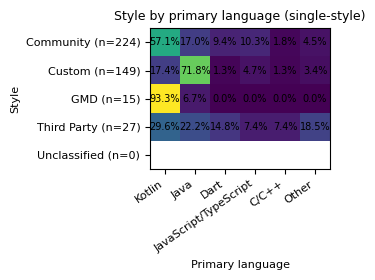

In [4]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CSV_PATH = Path(r"C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\ICST2026\5_Total_Repo.csv")
OUT_DIR  = CSV_PATH.parent / "images"
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_PNG = OUT_DIR / "rq2_obs22_style_by_language_heatmap.png"

SINGLE_COL_IN = 21/6  # 3.5 in

def pick_col(df: pd.DataFrame, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError(f"None of these columns exist: {candidates}")

STYLE_ORDER = ["Community", "Custom", "GMD", "Third Party", "Unclassified"]
LANG_ORDER  = ["Kotlin", "Java", "Dart", "JavaScript/TypeScript", "C/C++", "Other"]

def norm_style_token(tok: str) -> str | None:
    t = tok.strip().lower()
    if not t:
        return None
    if "community" in t: return "Community"
    if "custom" in t: return "Custom"
    if "gmd" in t or "managed" in t: return "GMD"
    if "third" in t or "device-lab" in t or "devicelab" in t: return "Third Party"
    if "real" in t and "device" in t: return "Real Device"
    if "unclassified" in t: return "Unclassified"
    return None

def extract_styles(cell: str) -> list[str]:
    toks = [p.strip() for p in str(cell).split(",")]
    out = []
    for tok in toks:
        s = norm_style_token(tok)
        if s:
            out.append(s)
    # de-dupe preserve order
    seen, uniq = set(), []
    for s in out:
        if s not in seen:
            uniq.append(s); seen.add(s)
    return uniq

def bucket_language(x: str) -> str:
    s = str(x).strip()
    # If your dataset already has these buckets, this will pass through.
    if s in LANG_ORDER:
        return s

    t = s.lower()
    if t == "kotlin": return "Kotlin"
    if t == "java": return "Java"
    if t == "dart": return "Dart"
    if "javascript" in t or "typescript" in t or t in {"js", "ts"}:
        return "JavaScript/TypeScript"
    if "c++" in t or t == "c" or "objective-c" in t or "objc" in t:
        return "C/C++"
    return "Other"

df = pd.read_csv(CSV_PATH, dtype=str).fillna("")

col_style = pick_col(df, ["Exec_Env_Style", "exec_env_style", "execution_environment_style"])
df["styles"] = df[col_style].apply(extract_styles)

# Single-style only, exclude Real Device from comparisons
df_single = df[df["styles"].apply(lambda xs: len(xs) == 1)].copy()
df_single["style"] = df_single["styles"].str[0]
df_single = df_single[df_single["style"] != "Real Device"].copy()

# language column candidates
col_lang = pick_col(df, ["primary_language", "language", "Language", "main_language", "lang_bucket", "language_bucket"])
df_single["lang_bucket"] = df_single[col_lang].apply(bucket_language)

# matrix = row% within each style
M = np.zeros((len(STYLE_ORDER), len(LANG_ORDER)), dtype=float)
N_by_style = {}

for i, st in enumerate(STYLE_ORDER):
    sub = df_single[df_single["style"] == st]
    n = len(sub)
    N_by_style[st] = n
    if n == 0:
        M[i, :] = np.nan
        continue
    for j, lg in enumerate(LANG_ORDER):
        M[i, j] = (sub["lang_bucket"].eq(lg).mean() * 100.0)

fig, ax = plt.subplots(figsize=(SINGLE_COL_IN, 2.9))
im = ax.imshow(M, aspect="auto")

ax.set_yticks(range(len(STYLE_ORDER)))
ax.set_yticklabels([f"{st} (n={N_by_style.get(st,0)})" for st in STYLE_ORDER], fontsize=8)

ax.set_xticks(range(len(LANG_ORDER)))
ax.set_xticklabels(LANG_ORDER, rotation=35, ha="right", fontsize=8)

for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        if np.isnan(M[i, j]): 
            continue
        ax.text(j, i, f"{M[i,j]:.1f}%", ha="center", va="center", fontsize=7)

ax.set_title("Style by primary language (single-style)", fontsize=9)
ax.set_xlabel("Primary language", fontsize=8)
ax.set_ylabel("Style", fontsize=8)

fig.tight_layout()
fig.savefig(OUT_PNG, dpi=300)
print(f"Saved: {OUT_PNG}")
plt.show()


In [ ]:
#observation 2.3

Saved: C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\ICST2026\images\rq2_obs23_comm_vs_custom_splitbeans.png


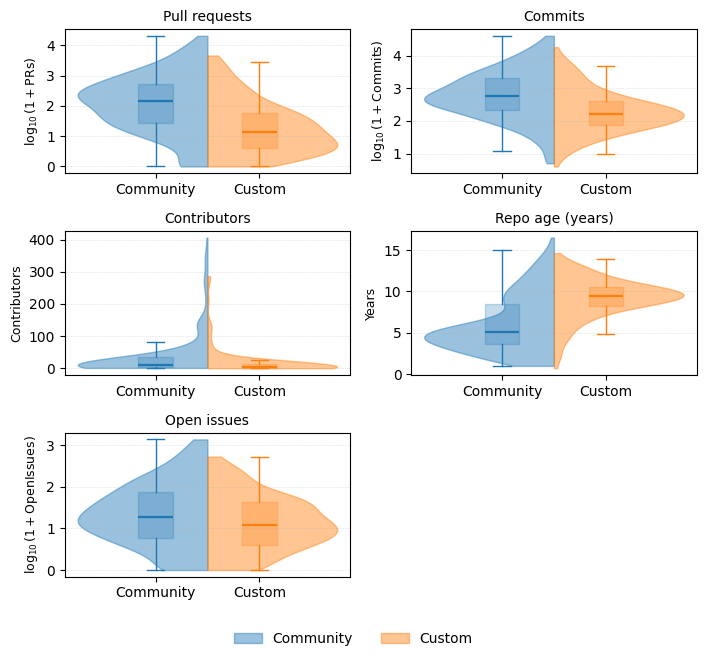

In [3]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

CSV_PATH = Path(r"C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\ICST2026\5_Total_Repo.csv")
OUT_DIR  = CSV_PATH.parent / "images"
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_PNG = OUT_DIR / "rq2_obs23_comm_vs_custom_splitbeans.png"

TEXT_WIDTH_IN = 43/6  # ~7.17 in (two-column)
ADOPTER_COLOR = "C0"  # used for Community
NONADOPTER_COLOR = "C1"  # used for Custom

def pick_col(df: pd.DataFrame, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError(f"None of these columns exist: {candidates}")

def transform_series(x: pd.Series, mode: str | None):
    x = pd.to_numeric(x, errors="coerce").dropna().to_numpy()
    if mode is None:
        return x
    if mode == "log10p1":
        return np.log10(1.0 + np.clip(x, a_min=0, a_max=None))
    raise ValueError(mode)

def norm_style_token(tok: str) -> str | None:
    t = tok.strip().lower()
    if not t:
        return None
    if "community" in t: return "Community"
    if "custom" in t: return "Custom"
    if "gmd" in t or "managed" in t: return "GMD"
    if "third" in t or "device-lab" in t or "devicelab" in t: return "Third Party"
    if "real" in t and "device" in t: return "Real Device"
    if "unclassified" in t: return "Unclassified"
    return None

def extract_styles(cell: str) -> list[str]:
    toks = [p.strip() for p in str(cell).split(",")]
    out = []
    for tok in toks:
        s = norm_style_token(tok)
        if s:
            out.append(s)
    seen, uniq = set(), []
    for s in out:
        if s not in seen:
            uniq.append(s); seen.add(s)
    return uniq

def split_violin_with_box(
    ax, data_left, data_right, title, y_label,
    center=1.0, width=0.9, box_offset=0.18, box_width=0.12,
    left_color=ADOPTER_COLOR, right_color=NONADOPTER_COLOR, alpha=0.45,
    left_name="Community", right_name="Custom",
    xtick_fontsize=9
):
    vp = ax.violinplot(
        [data_left, data_right],
        positions=[center, center],
        widths=width,
        showmeans=False,
        showmedians=False,
        showextrema=False,
    )
    bodies = vp["bodies"]
    if len(bodies) >= 2:
        # left half
        bL = bodies[0]
        bL.set_facecolor(left_color)
        bL.set_edgecolor(left_color)
        bL.set_alpha(alpha)
        v = bL.get_paths()[0].vertices
        v[v[:, 0] > center, 0] = center

        # right half
        bR = bodies[1]
        bR.set_facecolor(right_color)
        bR.set_edgecolor(right_color)
        bR.set_alpha(alpha)
        v = bR.get_paths()[0].vertices
        v[v[:, 0] < center, 0] = center

    ax.boxplot(
        [data_left],
        positions=[center - box_offset],
        widths=box_width,
        showfliers=False,
        manage_ticks=False,
        patch_artist=True,
        boxprops=dict(facecolor=left_color, edgecolor=left_color, alpha=0.25),
        whiskerprops=dict(color=left_color),
        capprops=dict(color=left_color),
        medianprops=dict(color=left_color, linewidth=1.6),
    )
    ax.boxplot(
        [data_right],
        positions=[center + box_offset],
        widths=box_width,
        showfliers=False,
        manage_ticks=False,
        patch_artist=True,
        boxprops=dict(facecolor=right_color, edgecolor=right_color, alpha=0.25),
        whiskerprops=dict(color=right_color),
        capprops=dict(color=right_color),
        medianprops=dict(color=right_color, linewidth=1.6),
    )

    ax.set_title(title, fontsize=10)
    ax.set_ylabel(y_label, fontsize=9)
    ax.set_xticks([center - box_offset, center + box_offset])
    ax.set_xticklabels([left_name, right_name], fontsize=xtick_fontsize)
    ax.grid(True, axis="y", linestyle=":", linewidth=0.5, alpha=0.6)

# =========================
# Load and filter (single-style only)
# =========================
df = pd.read_csv(CSV_PATH, dtype=str).fillna("")
col_style = pick_col(df, ["Exec_Env_Style", "exec_env_style", "execution_environment_style"])
df["styles"] = df[col_style].apply(extract_styles)

df_single = df[df["styles"].apply(lambda xs: len(xs) == 1)].copy()
df_single["style"] = df_single["styles"].str[0]

COMM = df_single[df_single["style"] == "Community"].copy()
CUST = df_single[df_single["style"] == "Custom"].copy()

# Metric columns
col_pr  = pick_col(df, ["pull_requests", "pull_request", "prs", "num_pull_requests"])
col_cm  = pick_col(df, ["commits_GitAPI", "commits", "num_commits"])
col_con = pick_col(df, ["contributors", "num_contributors"])
col_age = pick_col(df, ["repo_age", "age_years", "repository_age_years"])
col_iss = pick_col(df, ["open_issues_count", "open_issues", "issues_open"])

metrics = [
    (col_pr,  "Pull requests",      "log10p1", r"$\log_{10}(1+\mathrm{PRs})$"),
    (col_cm,  "Commits",            "log10p1", r"$\log_{10}(1+\mathrm{Commits})$"),
    (col_con, "Contributors",       None,     "Contributors"),
    (col_age, "Repo age (years)",   None,     "Years"),
    (col_iss, "Open issues",        "log10p1", r"$\log_{10}(1+\mathrm{OpenIssues})$"),
]

# =========================
# Plot: 2 columns per row
# =========================
fig, axes = plt.subplots(3, 2, figsize=(TEXT_WIDTH_IN, 6.6))
axes = axes.flatten()

for i, (col, title, tmode, ylab) in enumerate(metrics):
    comm_vals = transform_series(COMM[col], tmode)
    cust_vals = transform_series(CUST[col], tmode)
    split_violin_with_box(
        axes[i], comm_vals, cust_vals,
        title=title, y_label=ylab,
        left_color="C0", right_color="C1",
        left_name="Community", right_name="Custom",
        xtick_fontsize=10  # <-- adjust label size here if you want
    )

# hide unused last subplot
for j in range(len(metrics), len(axes)):
    axes[j].axis("off")

handles = [
    Patch(facecolor="C0", edgecolor="C0", alpha=0.45, label="Community"),
    Patch(facecolor="C1", edgecolor="C1", alpha=0.45, label="Custom"),
]
fig.legend(handles=handles, loc="lower center", ncol=2, frameon=False)

fig.tight_layout(rect=[0, 0.06, 1, 1])
fig.savefig(OUT_PNG, dpi=300)
print(f"Saved: {OUT_PNG}")
plt.show()
